# Datasets
In PyTorch abbiamo a disposizione due primitive per gestire i datasets:
- `torch.utilis.data.Dataset` che memorizza gli esempi e le labels associate
- `torch.utils.data.DataLoader` che fa da wrapper per `Dataset` e anche da iteratore.

## Loading a Dataset
Proviamo ad utilizzare il _Fashion-MNIST_ ovvero un dataset di immagini di vestiti ed accessori composto da 60,000 immagini di esempio e 10,000 di testing. Ogni esempio è composto da una griglia 28x28 in scala di grigi e una label appartenente ad una classe (10 in totale)

Vediamo i parametri necessari per caricare il dataset:
- `root`: Indica il path dove verrá salvato il dataset
- `train`: Specifica se vogliamo i dati di test o training
- `download`: Scarica i dati se non sono disponibili in `root`
- `transform` e `target_transform`: Specifica come vanno convertiti i dati

In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

## Iterating and Visualizing the Dataset
Possiamo pensare ai datasets come semplici liste e quindi iterarci sopra: `training_data[index]`, utilizziamo `matplotlib` per visualizzare qualche esempio del training dataset.

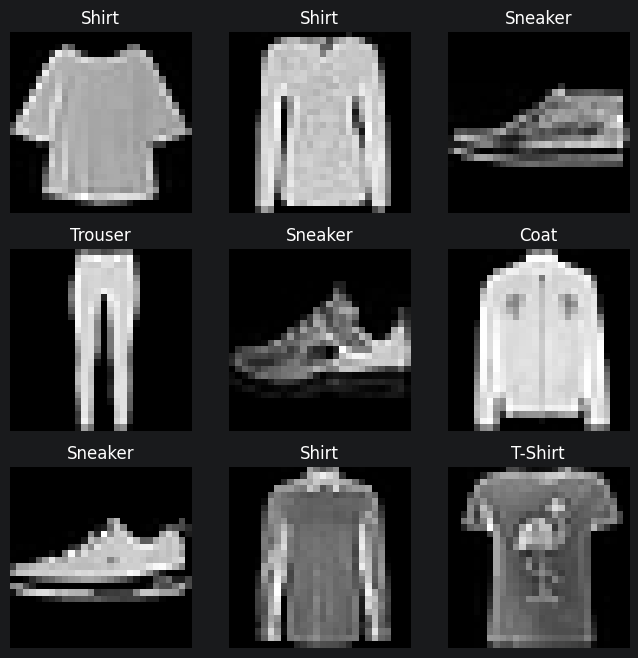

In [2]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

## Creating a Custom Dataset for your files
Un `Dataset` custom deve implementare tre funzioni: _\_\_init\_\__, _\_\_len\_\__ e _\_\_getitem\_\__.

Prendiamo come esempio il seguente codice e ipotizziamo di avere il FashionMNIST nella directory `img_dir` mentre le corrispondenti labels in un file CSV `annotations_file`

In [3]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

### _\_\_init\_\__
Questa funzione viene eseguita una sola volta alla creazione dell'oggetto, da notare che il file `.csv` avrà una formattazione simile alla seguente:
```
tshirt1.jpg, 0
tshirt2.jpg, 0
......
ankleboot999.jpg, 9
```

### _\_\_len\_\__
Questa funzione deve ritornare il numero di esempi presenti nel dataset.

### _\_\_getitem\_\__
Questa funzione, fornito un indice, deve prendere quell'esempio, transformarlo in tensor con `decode_image`, raccogliere la label corrispondente dal csv, chiamare la funzione transform specificata (se possibile) e ritornare una tupla contente il tensor dell'immagine e la label.

## Preparing your data for training with DataLoaders
La classe Dataset ispeziona gli esempi e le label uno alla volta. Durante l'allenamento di un modello però si preferisce passare gli esempi in "minibatches" e rimescolare i dati ad ogni epoch di addestramento per ridurre l'overfitting del modello, inoltre vogliamo anche utilizzare il multiprocessing di Python per velocizzare le cose.

`DataLoader` è un iterabile che astrae tutto questo in modo semplice:

In [5]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

### Iterate through the DataLoader
Adesso che abbiamo caricato i dati nel DataLoader possiamo iterarci sopra. Ogni iterazione restituisce una batch di `train_features` e `train_labels` (che in questo caso contengono 64 elementi ciascuna) e siccome abbiamo specificato `shuffle = True` dopo aver iterato su tutte le batch i dati verrano mescolati.

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


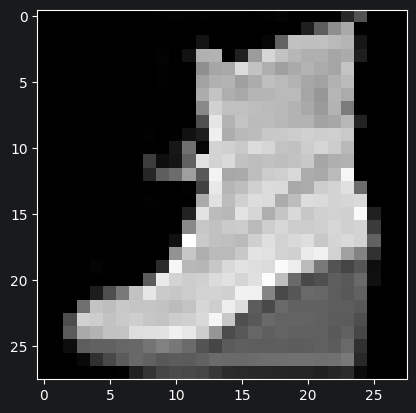

Label: 9


In [13]:
# Display image and label

# Qui il train_dataloader diventa un iterabile e prendiamo il prossimo elemento (una batch da 64 elementi)
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
# Qui prendiamo il primo elemento delle batch
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

# Transforms
I dati non sempre ci vengono forniti nella forma richiesta dall'algoritmo di apprendimento, utilizziamo transforms per effettuare queste modifiche ai dati.

Tutti i dataset TorchVision hanno due parametri:
- `transforms`: Per modificare le features
- `target_transform`: Per modificare le labels
Il modulo `torchvision.tranforms` ci offre diversi transforms già pronti.

Ad esempio, il FashionMNIST ha le immagini in formato PIL e le labels sono interi, per l'addrestramento abbiamo bisogno che sia immagini che labels diventino dei tensors, per le labels usiamo una codifica "one-hot" ovvero se abbiamo 10 classi avremo un tensor da 10 elementi con tutti 0 e un solo 1 sulla classe corrispondente. Per fare queste trasformazione useremo `ToTensor` e `Lambda`

In [16]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    # Scatter vuole su quale dimensione lavoriamo, l'indice (come tensore) e cosa mettere in quell'indice
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1)),
)

# PyTorch è lazy, per vedere effettivamente i cambiamenti dobbiamo chiamare un elemento
# Se si vuole vedere l'etichetta trasformata scommenta le righe
# immagine, etichetta = ds[0]
# print(etichetta)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])


- `ToTensor()` Converte l'immagine PIL o un ndarray di NumPy in un FloatTensor e scala l'intensità dei pixel dell'immagine nel range [0., 1.]
- `Lambda Transforms` Applica una funzione definita dall'utente, in questo caso creiamo un tensor da 10 elementi di tutti 0 e chiamiamo `scatter_` che assegna il valore 1 all'indice fornito dalla label `y`.